# Minimal MotrixSim Batch Gaussian Render

This notebook demonstrates minimal MotrixSim batch 3D Gaussian rendering.
It uses only local files under `assets/` plus installed Python packages (`motrixsim`, `gaussian_renderer`, `torch`, etc.).


In [1]:
from pathlib import Path

import mediapy
import numpy as np
from scipy.spatial.transform import Rotation
import torch
from motrixsim import SceneData, load_model, step

ROOT = Path(".")
ASSET_ROOT = ROOT / 'assets' / 'franka_emika_panda_robotiq'
GS_ASSET_ROOT = ASSET_ROOT
MJCF_PATH = ASSET_ROOT / 'xmls' / 'table30_00_simple_room.xml'
GS_ROOT = GS_ASSET_ROOT / '3dgs'

assert MJCF_PATH.exists(), MJCF_PATH

gaussians = {
    **{f'link{i}': (GS_ROOT / 'franka_224' / f'link{i}.ply').as_posix() for i in range(0, 8)},
    'hand': (GS_ROOT / 'robotiq_224' / 'hand.ply').as_posix(),
    'left_finger': (GS_ROOT / 'robotiq_224' / 'left_finger.ply').as_posix(),
    'right_finger': (GS_ROOT / 'robotiq_224' / 'right_finger.ply').as_posix(),
}
background = (GS_ROOT / 'background.ply').as_posix()

missing = [path for path in [*gaussians.values(), background] if not Path(path).exists()]
assert not missing, missing
print(f'MJCF: {MJCF_PATH.as_posix()}')
print(f'Gaussian root: {GS_ROOT.as_posix()}')
print(f'Loaded {len(gaussians)} body gaussian files')
CUDA_AVAILABLE = torch.cuda.is_available()
print(f'CUDA available: {CUDA_AVAILABLE}')


MJCF: assets/franka_emika_panda_robotiq/xmls/table30_00_simple_room.xml
Gaussian root: assets/franka_emika_panda_robotiq/3dgs
Loaded 11 body gaussian files
CUDA available: True


Motphys profiler initialized: disabled


## Single Environment Smoke Test


Loaded model: 1 bodies, 1 camera(s)
Gaussian/model body mapping OK: ['link0', 'link1', 'link2', 'link3', 'link4', 'link5', 'link6', 'link7', 'hand', 'left_finger', 'right_finger']


W0429 03:35:01.605000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/0] q1 is not in var_ranges, defaulting to unknown range.
W0429 03:35:01.632000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/0] q1 is not in var_ranges, defaulting to unknown range.
W0429 03:35:01.664000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/0] z1 is not in var_ranges, defaulting to unknown range.
W0429 03:35:01.683000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/0] z1 is not in var_ranges, defaulting to unknown range.
W0429 03:35:01.770000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/0] x0 is not in var_ranges, defaulting to unknown range.
W0429 03:35:01.796000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/0] x0 is not in var_ranges, defaulting to unknown range.
/home/xyys2003/ws/gsp/dev/.venv/lib/python3.10/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST 

camera=0, rgb=(240, 320, 3), depth=(240, 320, 1)


""

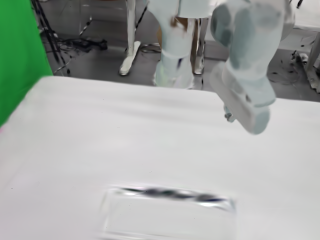

In [2]:
mx_model = load_model(MJCF_PATH.as_posix())
mx_data = SceneData(mx_model)
mx_model.keyframes[0].apply(mx_data)
step(mx_model, mx_data)
print(f'Loaded model: {mx_model.num_bodies} bodies, {len(mx_model.cameras)} camera(s)')
model_body_names = [link.name for link in mx_model.links if link.name]
missing_body_names = sorted(set(gaussians) - set(model_body_names))
assert not missing_body_names, f'Gaussian keys not found in model links: {missing_body_names}; available: {model_body_names}'
print('Gaussian/model body mapping OK:', model_body_names)

if CUDA_AVAILABLE:
    from gaussian_renderer import GSRendererMotrixSim
    single_gaussians = dict(gaussians, background=background)
    single_renderer = GSRendererMotrixSim(single_gaussians, mx_model)
    single_renderer.update_gaussians(mx_data)
    single_results = single_renderer.render(mx_model, mx_data, list(range(len(mx_model.cameras))), 320, 240)

    for camera_id, (rgb, depth) in single_results.items():
        print(f'camera={camera_id}, rgb={tuple(rgb.shape)}, depth={tuple(depth.shape)}')
        mediapy.show_image(rgb.cpu().numpy())
else:
    print('Skip single-environment Gaussian render because CUDA is not available.')


## Batch Environment Render


In [3]:
# Keep this small for a portable smoke test. Increase to 2048 for the original benchmark scale.
NUM_ENV = 256
H, W = 480, 640
MINIBATCH = NUM_ENV

mx_model = load_model(MJCF_PATH.as_posix())
mx_data = SceneData(mx_model, batch=(NUM_ENV,))
mx_model.keyframes[0].apply(mx_data)
step(mx_model, mx_data)

link_poses = mx_model.get_link_poses(mx_data)
body_pos = link_poses[..., :3]
body_quat = link_poses[..., 3:]  # xyzw
quat_norm = np.linalg.norm(body_quat, axis=-1)
assert quat_norm.min() > 1 - 1e-6 and quat_norm.max() < 1 + 1e-6
print('body_pos:', body_pos.shape, 'body_quat:', body_quat.shape)


body_pos: (256, 11, 3) body_quat: (256, 11, 4)


W0429 03:35:03.141000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/1] q2 is not in var_ranges, defaulting to unknown range.
W0429 03:35:03.171000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/1] q2 is not in var_ranges, defaulting to unknown range.
W0429 03:35:03.214000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/1] z2 is not in var_ranges, defaulting to unknown range.
W0429 03:35:03.235000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/1] z2 is not in var_ranges, defaulting to unknown range.
W0429 03:35:03.381000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/1] x0 is not in var_ranges, defaulting to unknown range.
W0429 03:35:03.415000 140074482566976 torch/fx/experimental/symbolic_shapes.py:4449] [0/1] x0 is not in var_ranges, defaulting to unknown range.


rgb: (256, 1, 480, 640, 3) depth: (256, 1, 480, 640, 1)
Saved render preview: outputs/mtx_batch_render_preview.png


""

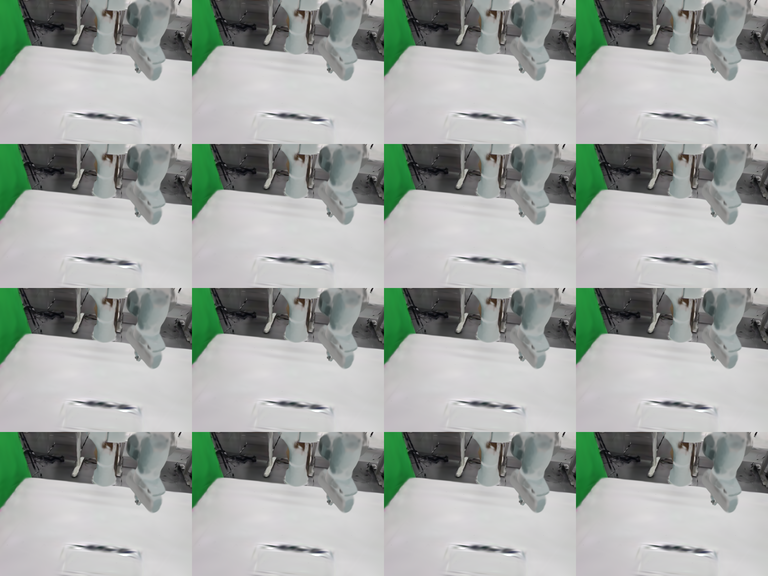

In [4]:
if CUDA_AVAILABLE:
    from gaussian_renderer import BatchSplatConfig, MtxBatchSplatRenderer
    renderer = MtxBatchSplatRenderer(
        BatchSplatConfig(body_gaussians=gaussians, background_ply=None, minibatch=MINIBATCH),
        mx_model,
    )
    gsb = renderer.batch_update_gaussians(body_pos, body_quat)

    cam_pos_list = []
    cam_xmat_list = []
    fovy_list = []
    for cam in mx_model.cameras:
        cam_pose = cam.get_pose(mx_data)
        cam_pos_list.append(cam_pose[..., :3])
        cam_xmat_list.append(Rotation.from_quat(cam_pose[..., 3:7]).as_matrix().reshape(NUM_ENV, 9))
        fovy_list.append(cam.fovy)

    cam_pos = np.array(cam_pos_list).transpose(1, 0, 2)
    cam_xmat = np.array(cam_xmat_list).transpose(1, 0, 2)
    fovy = np.tile(np.array(fovy_list), (NUM_ENV, 1))

    bg_renderer = MtxBatchSplatRenderer(
        BatchSplatConfig(body_gaussians={}, background_ply=background, minibatch=NUM_ENV),
        mx_model,
    )
    bg_gsb = bg_renderer.batch_update_gaussians(body_pos, body_quat)
    bg_imgs, _ = bg_renderer.batch_env_render(bg_gsb, cam_pos, cam_xmat, H, W, fovy)

    rgb, depth = renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy, bg_imgs)
    print('rgb:', tuple(rgb.shape), 'depth:', tuple(depth.shape))

    def tile_square(images):
        images = images.cpu().numpy() if hasattr(images, "cpu") else np.asarray(images)
        d = int(np.sqrt(images.shape[0]))
        assert d * d == images.shape[0], images.shape
        grid = images[: d * d].reshape((d, d) + images.shape[1:])
        return np.concatenate(np.concatenate(grid, axis=1), axis=1)

    render_preview = tile_square(rgb[:16, 0])
    preview_path = ROOT / 'outputs' / 'mtx_batch_render_preview.png'
    preview_path.parent.mkdir(parents=True, exist_ok=True)
    mediapy.write_image(preview_path.as_posix(), np.clip(render_preview, 0.0, 1.0))
    print(f'Saved render preview: {preview_path.as_posix()}')
    mediapy.show_image(render_preview, width=768)


else:
    print('Skip batch Gaussian render because CUDA is not available.')


## Optional Timing


In [5]:
if globals().get('CUDA_AVAILABLE', torch.cuda.is_available()) and 'renderer' in globals():
    cam_pos_t = torch.as_tensor(cam_pos, device=renderer.device, dtype=torch.float32)
    cam_xmat_t = torch.as_tensor(cam_xmat, device=renderer.device, dtype=torch.float32)

    for _ in range(5):
        renderer.batch_env_render(gsb, cam_pos_t, cam_xmat_t, H, W, fovy, bg_imgs)
    torch.cuda.synchronize()

    elapsed_ms = []
    for _ in range(20):
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        start_event.record()
        renderer.batch_env_render(gsb, cam_pos_t, cam_xmat_t, H, W, fovy, bg_imgs)
        end_event.record()
        torch.cuda.synchronize()
        elapsed_ms.append(start_event.elapsed_time(end_event))
    avg_ms = float(np.mean(elapsed_ms))
    ips = NUM_ENV * len(mx_model.cameras) / (avg_ms / 1000.0)
    print(f'Average render time over {len(elapsed_ms)} runs: {avg_ms:.3f} ms')
    print(f'Throughput: {ips:.1f} images/s')
else:
    print('CUDA render was skipped; skip GPU timing.')


Average render time over 20 runs: 115.833 ms
Throughput: 2210.1 images/s


## Optional Timing With Gaussian Update


In [6]:
if globals().get('CUDA_AVAILABLE', torch.cuda.is_available()) and 'renderer' in globals():
    cam_pos_t = torch.as_tensor(cam_pos, device=renderer.device, dtype=torch.float32)
    cam_xmat_t = torch.as_tensor(cam_xmat, device=renderer.device, dtype=torch.float32)

    for _ in range(5):
        gsb_timed = renderer.batch_update_gaussians(body_pos, body_quat)
        renderer.batch_env_render(gsb_timed, cam_pos_t, cam_xmat_t, H, W, fovy, bg_imgs)
    torch.cuda.synchronize()

    elapsed_ms = []
    for _ in range(200):
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        start_event.record()
        gsb_timed = renderer.batch_update_gaussians(body_pos, body_quat)
        renderer.batch_env_render(gsb_timed, cam_pos_t, cam_xmat_t, H, W, fovy, bg_imgs)
        end_event.record()
        torch.cuda.synchronize()
        elapsed_ms.append(start_event.elapsed_time(end_event))

    avg_ms = float(np.mean(elapsed_ms))
    ips = NUM_ENV * len(mx_model.cameras) / (avg_ms / 1000.0)
    print(f'Average update+render time over {len(elapsed_ms)} runs: {avg_ms:.3f} ms')
    print(f'Update+render throughput: {ips:.1f} images/s')
else:
    print('CUDA render was skipped; skip update+render GPU timing.')


Average update+render time over 200 runs: 124.761 ms
Update+render throughput: 2051.9 images/s
